In [55]:
import numpy as np

from src import Model

consumer_domain = np.array([[-2, 2]])
resource_domain = np.array([[-2, 2]])
mutation_rate = 0.001

EjemploPerthame = Model(consumer_domain, resource_domain, mutation_rate)

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))


def constante_en_intervalo(
    x: np.ndarray,
    const: float,
    a: float,
    b: float,
) -> np.ndarray:
    return const * ((a <= x) & (x <= b))


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    return np.full_like(z, const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    norm = np.abs(x - y) ** 2
    exp = np.exp(-norm / (2 * sigma_K**2))
    return exp / (sigma_K * np.sqrt(2 * np.pi))


def supply_rate_gaussiano(y: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    exp = np.exp(-(y**2) / (2 * sigma_in**2))
    return M_in * exp / (sigma_in * np.sqrt(2 * np.pi))


EjemploPerthame.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=0.5)
)
EjemploPerthame.set_consumer_growth_rate(lambda x: funcion_constante(x, const=1.0))
EjemploPerthame.set_consumer_decay(lambda x: funcion_constante(x, const=0.5))
EjemploPerthame.set_resource_supply_rate(
    lambda y: supply_rate_gaussiano(y, sigma_in=1.0, M_in=3.0)
)
EjemploPerthame.set_resource_decay(lambda y: funcion_constante(y, const=0.5))
EjemploPerthame.set_initial_data(
    initial_consumer_distribution=lambda x: gauss(x, -0.3, 0.003, 2.5),
    initial_resource_distribution=lambda y: constante_en_intervalo(y, 20.0, -2, -1),
)

In [56]:
T = 250

EjemploPerthame.solve_by_finite_differences(
    T=T,
    n_t=200 * T,
    n_x=2000,
    n_y=2000,
    border_type="neumann",
    use_stationary_resource=True,
)

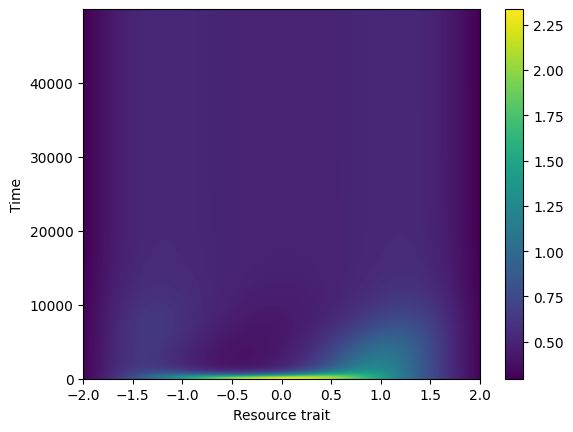

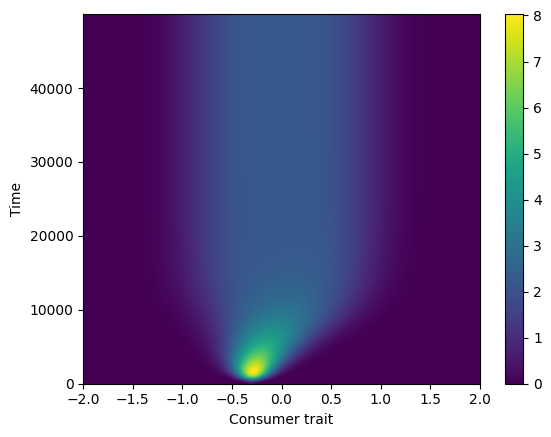

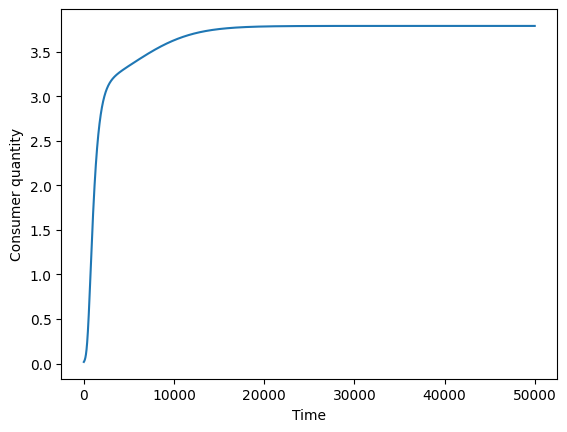

In [57]:
EjemploPerthame.plot.solution_over_time(
    solution="resource",
    plot_type="heatmap",
    # color="red",
    # linestyle="--",
    # linewidth=3,
    # marker="o",
)
EjemploPerthame.plot.solution_over_time(
    solution="consumer-density",
    plot_type="heatmap",
    # color="red",
    # linestyle="--",
    # linewidth=3,
    # marker="o",
)
EjemploPerthame.plot.solution_over_time(
    solution="consumer-quantity",
    plot_type="heatmap",
    # color="red",
    # linestyle="--",
    # linewidth=3,
    # marker="o",
)